In [4]:
import gurobipy as gp
from gurobipy import GRB

import numpy as np
import pandas as pd

In [5]:
data = pd.read_csv('ex1data1.txt', sep=',', header=None)

In [6]:
print(data.head())

        0        1
0  6.1101  17.5920
1  5.5277   9.1302
2  8.5186  13.6620
3  7.0032  11.8540
4  5.8598   6.8233


In [7]:
print(data.shape)

(97, 2)


In [8]:
print(data.info)

<bound method DataFrame.info of           0         1
0    6.1101  17.59200
1    5.5277   9.13020
2    8.5186  13.66200
3    7.0032  11.85400
4    5.8598   6.82330
..      ...       ...
92   5.8707   7.20290
93   5.3054   1.98690
94   8.2934   0.14454
95  13.3940   9.05510
96   5.4369   0.61705

[97 rows x 2 columns]>


In [9]:
print(data.isnull().sum())

0    0
1    0
dtype: int64


In [10]:
print(data.duplicated().sum())

0


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

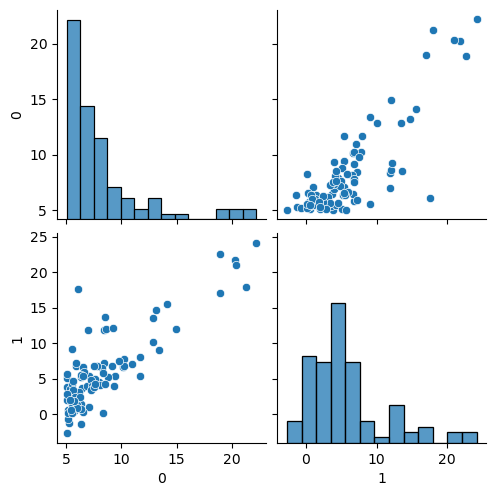

In [13]:
sns.pairplot(data)
plt.show()

In [14]:
corr = data.corr(numeric_only=True)
print(corr)

          0         1
0  1.000000  0.837873
1  0.837873  1.000000


In [23]:
X = data[0]
Y = data[1]
print(X.head())
print(X.max(), ":", X.min())
print(Y.head())
print(Y.max(), ":", Y.min())

0    6.1101
1    5.5277
2    8.5186
3    7.0032
4    5.8598
Name: 0, dtype: float64
22.203 : 5.0269
0    17.5920
1     9.1302
2    13.6620
3    11.8540
4     6.8233
Name: 1, dtype: float64
24.147 : -2.6807


In [32]:
m = gp.Model("LinearRegression")

In [33]:
a = m.addVar(lb=-100, ub=100, name="a")
b = m.addVar(lb=-100, ub=100, name="b")

In [34]:
m.setObjective(
    gp.quicksum( (Y[i] - (a * X[i] + b)) ** 2 for i in range(len(X)) ),
    #gp.quicksum( pow((Y[i] - (a * X[i] + b)), 2) for i in range(len(X)) ),
    GRB.MINIMIZE
)

In [35]:
m.optimize()

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: 12th Gen Intel(R) Core(TM) i3-12100, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 0 rows, 2 columns and 0 nonzeros (Min)
Model fingerprint: 0x24215a38
Model has 2 linear objective coefficients and an objective constant of 6.2221103722263970e+03
Model has 3 quadratic objective terms
Coefficient statistics:
  Matrix range     [0e+00, 0e+00]
  Objective range  [1e+03, 1e+04]
  QObjective range [2e+02, 2e+04]
  Bounds range     [1e+02, 1e+02]
  RHS range        [0e+00, 0e+00]

Presolve time: 0.01s
Presolved: 0 rows, 2 columns, 0 nonzeros
Presolved model has 3 quadratic objective terms
Ordering time: 0.00s

Barrier statistics:
 Free vars  : 1
 AA' NZ     : 0.000e+00
 Factor NZ  : 1.000e+00
 Factor Ops : 1.000e+00 (less than 1 second per iteration)
 Threads    : 1

                  Objective                Residua

In [36]:
if m.status == GRB.OPTIMAL:
    print('Optimal solution found')
elif m.status == GRB.UNBOUNDED:
    print('Unbounded solution found')
elif m.status == GRB.INFEASIBLE:
    print('Infeasible solution found')
else:
    print('Optimal solution Not found')
    
for v in m.getVars():
    print('%s %g' % (v.varName, v.x))


Optimal solution found
a 1.19303
b -3.89578
